Chargement des données


In [1]:
import pandas as pd

df = pd.read_csv("video_logs.csv")

df.head()

,user_id,video_id,event,timestamp,video_duration,device,country,age
0,1,8,play,0,442,Tablet,Italy,19
1,1,8,seek,55,442,Tablet,Italy,19
2,1,8,pause,294,442,Tablet,Italy,19
3,1,8,seek,365,442,Tablet,Italy,19
4,1,8,stop,375,442,Tablet,Italy,19


Répartition des événements

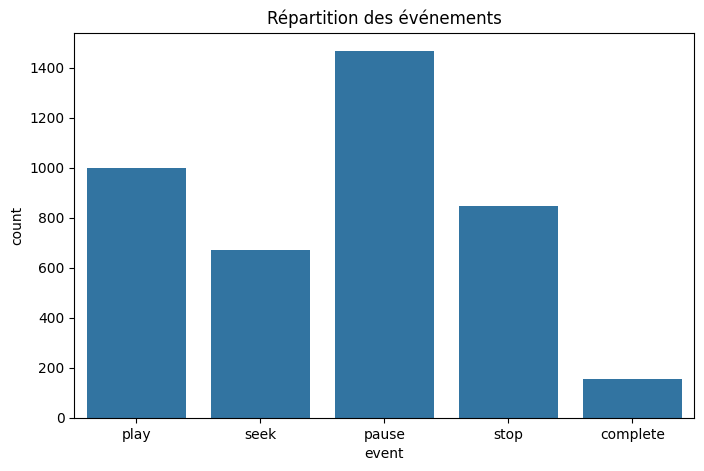

In [11]:
# Analyse de la fréquence des différents événements (play, pause, seek, stop, complete) afin de comprendrele comportement général des utilisateurs.


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="event")

plt.title("Répartition des événements")
plt.show()

Répartition des appareils

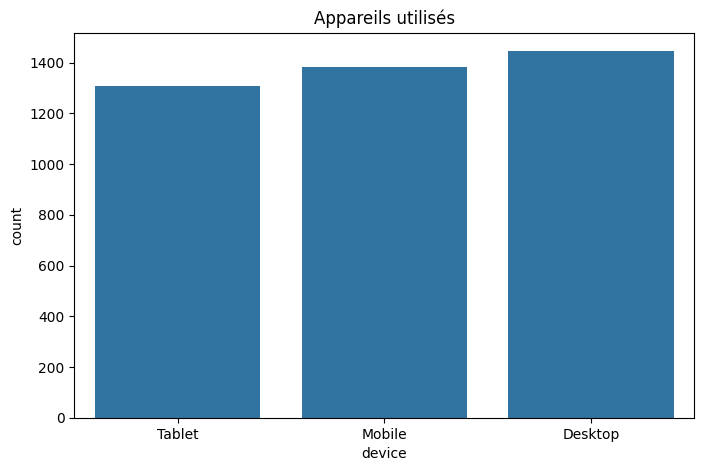

In [12]:
# Identification des appareils les plus utilisés pour consulter les vidéos de la plateforme.

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="device")

plt.title("Appareils utilisés")
plt.show()

Répartition des pays

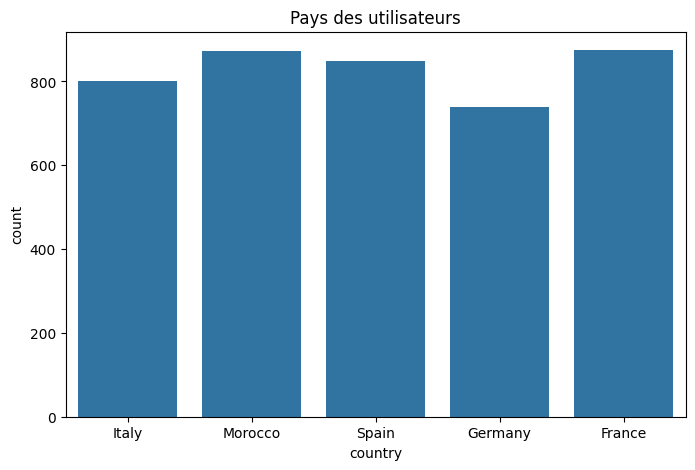

In [4]:
# Analyse géographique des utilisateurs afin d'identifier les principaux pays représentés.

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="country")

plt.title("Pays des utilisateurs")
plt.show()

Distribution des âges

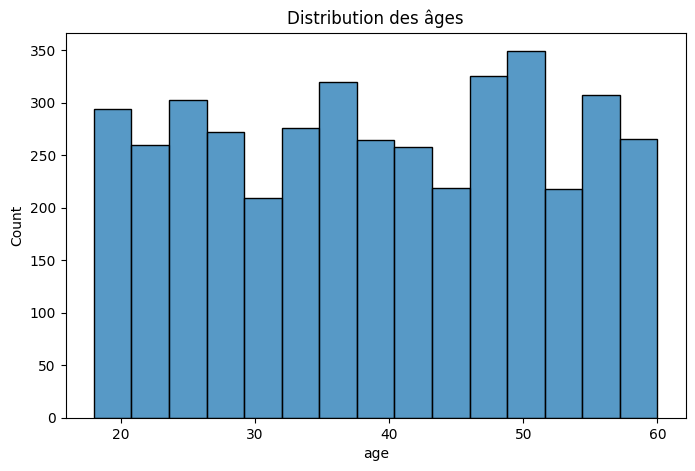

In [5]:
# Étude de la répartition des âges des utilisateurs pour mieux comprendre le profil de l'audience.

plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=15)

plt.title("Distribution des âges")
plt.show()

Détection des zones d'ennui

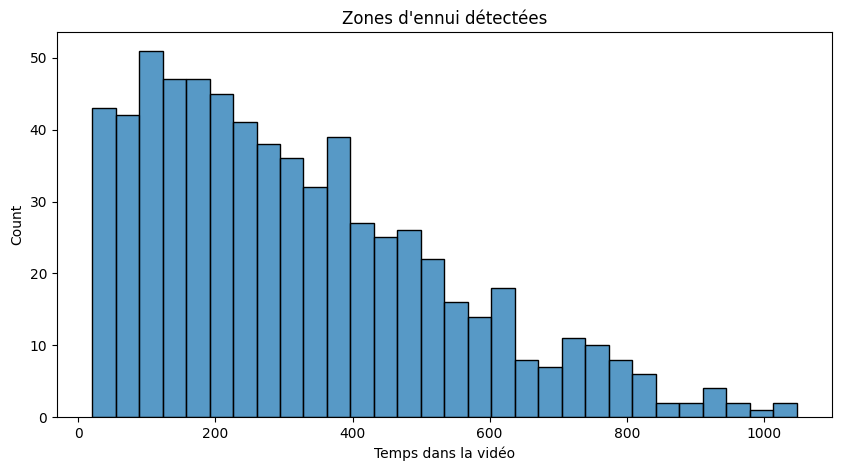

In [6]:
# Analyse des événements "seek" (avance rapide) Une forte concentration de seeks peut indiquer une perte d'intérêt à certains moments de la vidéo.

seek_df = df[df["event"] == "seek"]

plt.figure(figsize=(10,5))

sns.histplot(
    seek_df["timestamp"],
    bins=30
)

plt.title("Zones d'ennui détectées")
plt.xlabel("Temps dans la vidéo")
plt.show()

Calcul du taux de complétion

In [7]:
# Calcul du pourcentage d'utilisateurs ayant regardé la vidéo jusqu'à la fin par rapport aux abandons.

final_events = df[
    df["event"].isin(["complete","stop"])
]

completion_rate = (
    final_events["event"]
    .eq("complete")
    .mean()
    * 100
)

print(
    f"Taux de complétion : {completion_rate:.2f}%"
)

Taux de complétion : 15.50%


Graphique du taux de complétion

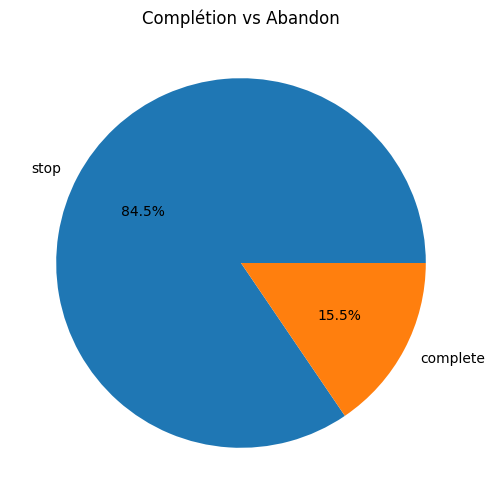

In [8]:
# Visualisation du rapport entre les vidéos terminées et les vidéos abandonnées avant la fin.

counts = final_events["event"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%"
)

plt.title("Complétion vs Abandon")
plt.show()

Popularité des vidéos

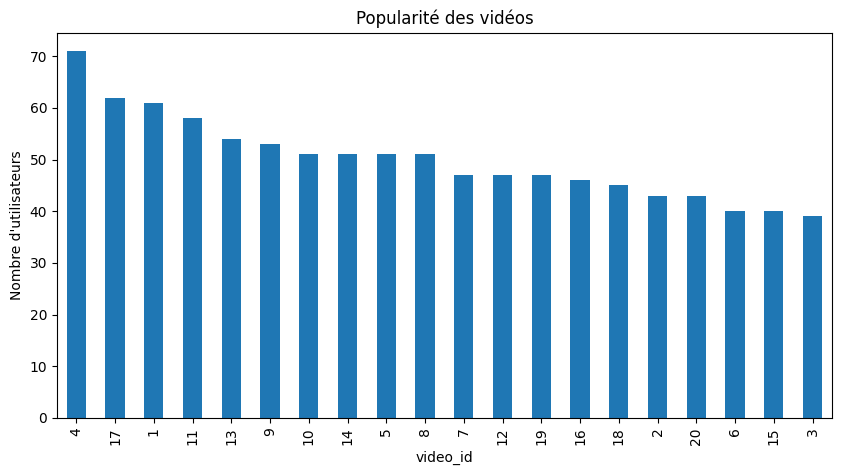

In [9]:
# Classement des vidéos selon le nombre d'utilisateurs uniques les ayant visionnées.

video_views = (
    df.groupby("video_id")["user_id"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

video_views.plot(kind="bar")

plt.title("Popularité des vidéos")
plt.ylabel("Nombre d'utilisateurs")
plt.show()

Heatmap des événements

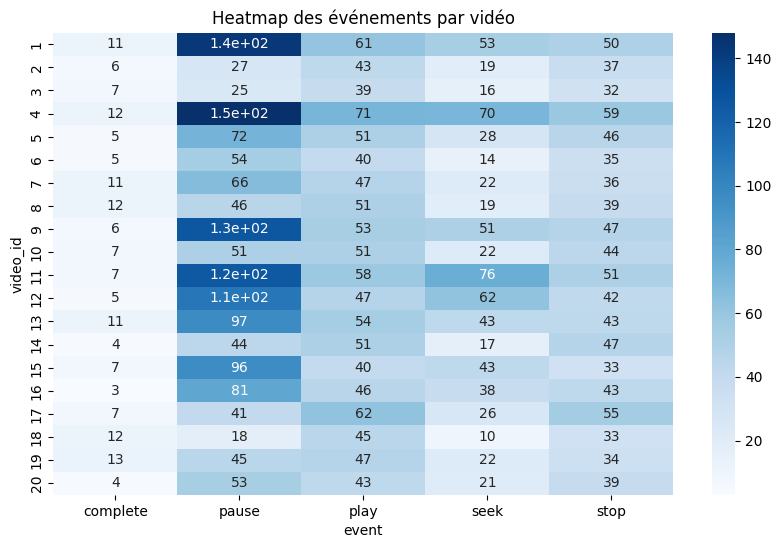

In [10]:
# Représentation visuelle des événements par vidéo. Cette heatmap permet d'identifier rapidement les comportements dominants pour chaque contenu.

pivot = pd.crosstab(
    df["video_id"],
    df["event"]
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Blues"
)

plt.title("Heatmap des événements par vidéo")
plt.show()